In [1]:
#Packages we need to have ( Install)
#import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
import random
#import os
#import time
#import sys

def read_data(file_name, method1=None, method2=None):

    # Initialize data as None
    data = None
    
    # Conditionally load data
    if method1 is not None:
        data1 = pd.read_excel(file_name, sheet_name=method1, header=0, index_col=0)
        data = data1  # Assume data1 is the default data

    if method2 is not None:
        data2 = pd.read_excel(file_name, sheet_name=method2, header=0, index_col=0)
        if data1 is not None:  # If data1 was also loaded
            data1 = data1.drop('Class', axis=1)
            data = pd.concat([data1, data2], axis=1, ignore_index=False)
        else:
            data = data2  # If only data2 was loaded

    # If both method1 and method2 are None, you might want to raise an error or handle it differently
    if data is None:
        raise ValueError("At least one method must be specified.")
    
    return data

def compute_enrichment( x, labels, probabilities, frac_true_actives):
    '''x is the enrichment factor threshold as a fraction (e.g. 0.1 for EF10%)
       True-labels is a list of 0 or 1 for each molecule
       probabilities gives the probability for each prediction (used to sort the lists)
       frac_true_actives is the fraction of the whole testing dataset that is active
       returns the enrichment factor at the level given by 'x'

    Notes:
       EF(x%) = {Hits_found_in_subset/N_mols_in_subset} / {Hits_total/Ntotal}   
    or
       EF(x%) = frac_hits_found_in_subset_to_x% / frac_mols_in_subset_to_x%
    '''
    
    # assumes labels are 1 and 0 (for 'active' and 'inactive')    
    assert(len(labels)==len(probabilities))
    zippedlist = list(zip(probabilities,labels))
        
    random.shuffle(zippedlist)     # avoid accidental enrichment if lots of entries have same probability and list is pre-sorted
    zippedlist.sort()
    zippedlist.sort(reverse=True)
    
    nsubset = int( (len(zippedlist)-1) * x ) + 1
    n_active_at_ef_threshold = len([x for x,y in zippedlist[:nsubset] if y == 1])

    # EF(x%) = {Hits_selected/N_subset} / {Hits_total/Ntotal}
    # EF(x%) = {Hits_selected/N_subset} / {frac_true_actives}
    enrichment = n_active_at_ef_threshold/(nsubset*frac_true_actives)
    
    #print(f'Enrichment at {x*100:.2f} % is {enrichment}.') #' Pr at cutoff is {mylist[cutoffindex]}')
    
    return enrichment



In [ ]:
train_data = read_data('MAPK1_T_filtrato.xlsx',  method1='MD')
validation_data = read_data('MAPK1_V_filtrato.xlsx',  method1='MD')
train_data.shape

(47131, 26)

In [5]:
len(validation_data)

15708

In [7]:
# Finding columns with zero variance in both training and Validation
# We only remove those columns which have zero variance in both training and validation to keep consistency from both
# training dimensionality and validation dimensionality.  
zero_variance_columns_train = train_data.columns[train_data.nunique() == 1]
zero_variance_columns_validation = validation_data.columns[validation_data.nunique() == 1]

# Finding common columns with zero variance in both datasets
common_zero_variance_columns = zero_variance_columns_train.intersection(zero_variance_columns_validation)

# Removing columns with zero variance from both datasets
train_data_cleaned = train_data.drop(columns=common_zero_variance_columns)
validation_data_cleaned = validation_data.drop(columns=common_zero_variance_columns)

# Number of columns removed
num_columns_removed = len(common_zero_variance_columns)
num_columns_removed


0

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix
#import shap

def binary_classification_with_svm(file_name, train_data, train_label, validation_data, validation_label):
    # Ensure the label variable is in the right format for the next steps
    if isinstance(train_label, pd.Series):
        train_label = train_label.values
    if isinstance(validation_label, pd.Series):
        validation_label = validation_label.values
    
    # Standardize the features
    scaler = StandardScaler()
    train_data_scaled = scaler.fit_transform(train_data)
    validation_data_scaled = scaler.transform(validation_data)
    
    # Initialize lists to store metrics and SHAP values
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    #fig, ax = plt.subplots()
    fp_indices = []
    fn_indices = []
    enrichMent = []
    
    classifier = SVC(kernel='rbf', class_weight='balanced', probability=True)
    classifier.fit(train_data_scaled, train_label)
    probas_ = classifier.predict_proba(validation_data_scaled)
    
    y_test = validation_label
    num_of_test_active = [x for x in y_test if x != 0]
    num_of_test_inactive = [x for x in y_test if x != 1]
    frac_true_actives = len(num_of_test_active) / (len(num_of_test_inactive) + len(num_of_test_active))
    
    x = 0.01  # EF percentage
    e = compute_enrichment(x, y_test, probas_[:, 1], frac_true_actives)
    enrichMent.append(e)
    
    # Compute ROC curve and area of the curve
    fpr, tpr, thresholds = roc_curve(validation_label, probas_[:, 1])
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
    
    # Compute false positives and negatives
    predictions = classifier.predict(validation_data_scaled)
    cm = confusion_matrix(validation_label, predictions)
    fp = np.where((predictions == 1) & (validation_label == 0))[0]
    fn = np.where((predictions == 0) & (validation_label == 1))[0]
    fp_indices.append(fp)
    fn_indices.append(fn)
    
    # Plot average ROC-AUC
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    
    plt.plot(mean_fpr, mean_tpr, color='b',
             label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
             lw=2, alpha=0.8)
    
    # Add the diagonal dashed line
    plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
    
    plt.title(f"ROC-AUC plot for {file_name}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.savefig(f"{file_name}_roc_auc.png")
    
    # Calculate and print average and standard deviation for AUC, FP, and FN
    auc_avg = np.mean(aucs)
    auc_std = np.std(aucs)
    
    fp_avg = np.mean([len(fp) for fp in fp_indices])
    fn_avg = np.mean([len(fn) for fn in fn_indices])
    print(f"AUC: {auc_avg}, Std: {auc_std}")
    print(f"FP: {fp_avg}, FN Avg: {fn_avg}")
    
    # Map FP and FN indices to original data for further investigation
    fp_mapped = np.concatenate(fp_indices)
    fn_mapped = np.concatenate(fn_indices)
    Ef_1percent = pd.DataFrame(enrichMent)
    return Ef_1percent, auc_avg, auc_std, fp_mapped, fn_mapped


AUC: 0.948051948051948, Std: 0.0
FP: 0.0, FN Avg: 59.0


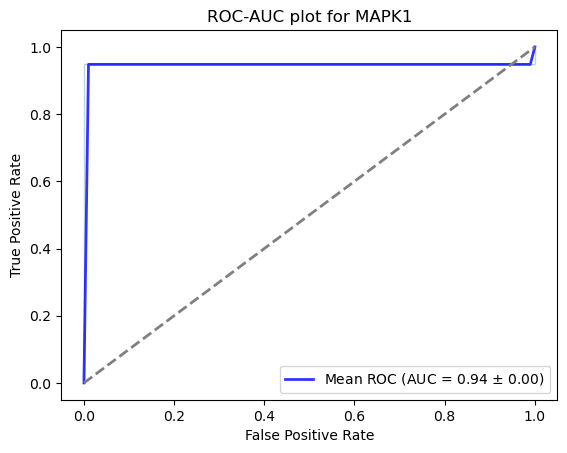

In [9]:
# Assuming 'data' contains features and 'Class' is the label column
train_data_prep = train_data_cleaned.drop('Class', axis=1)  # Adjust 'label' to your actual label column name
train_label = train_data_cleaned['Class']
validation_data_prep = validation_data_cleaned.drop('Class', axis=1)  # Adjust 'label' to your actual label column name
validation_label = validation_data_cleaned['Class']
Ef_1percent, auc_avg, auc_std, fp_mapped, fn_mapped = binary_classification_with_svm('MAPK1', train_data_prep, train_label, validation_data_prep, validation_label)

In [10]:

# Map indices back to molecule identifiers
fp_molecules = validation_data_prep.iloc[fp_mapped]
fn_molecules = validation_data_prep.iloc[fn_mapped]

# print the false-positive molecule indecies and their corresponding features
fp_molecules

#save fp_molecules as a csv file
#fp_molecules.to_csv('fp_molecules.csv', index=True)

# print the false-negative molecule indecies and their corresponding features
fn_molecules

#save fn_molecules as a csv file
#fn_molecules.to_csv('fn_molecules.csv', index=True)

EF_avg = np.mean(Ef_1percent[0])
EF_std = np.std(Ef_1percent[0])
df_summary = pd.DataFrame({'Metric': ['AUC', 'EF '],
                           'Value': [auc_avg, EF_avg ]})

df_summary.to_csv('MD_AUC_stat.csv')
df_summary


,Metric,Value
0,AUC,0.948052
1,EF,94.253165
